<a href="https://colab.research.google.com/github/chhaybilindaHak/assesment_coursework2/blob/main/W1941231_coursework2_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-bq0onrg4
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-bq0onrg4
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
#numpy and pandas will be used for data manipulationh
import numpy as np
import pandas as pd
#matplotib will be used for visually representing our data
import matplotlib.pyplot as plt
#yfinance will be used for importing historical oil prices
import yfinance as yfin

In [ ]:
#setting our ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)

#importing our data
data = ticker.history(period='5y')

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-11-25 00:00:00-05:00,157.093506,159.899994,157.013000,159.253494,75808000,0.0,0.0
2020-11-27 00:00:00-05:00,160.563004,160.809494,159.502502,159.766998,47858000,0.0,0.0
2020-11-30 00:00:00-05:00,160.423996,161.419495,156.277496,158.401993,81278000,0.0,0.0
2020-12-01 00:00:00-05:00,159.425003,162.447495,157.858994,161.003998,90740000,0.0,0.0
2020-12-02 00:00:00-05:00,161.082504,161.600006,158.662994,160.176498,62586000,0.0,0.0
...,...,...,...,...,...,...,...
2025-11-19 00:00:00-05:00,223.740005,223.740005,218.520004,222.690002,58335600,0.0,0.0
2025-11-20 00:00:00-05:00,227.050003,227.410004,216.740005,217.139999,50309000,0.0,0.0
2025-11-21 00:00:00-05:00,216.350006,222.210007,215.179993,220.690002,68490500,0.0,0.0


<Axes: xlabel='Date', ylabel='Amazon'>

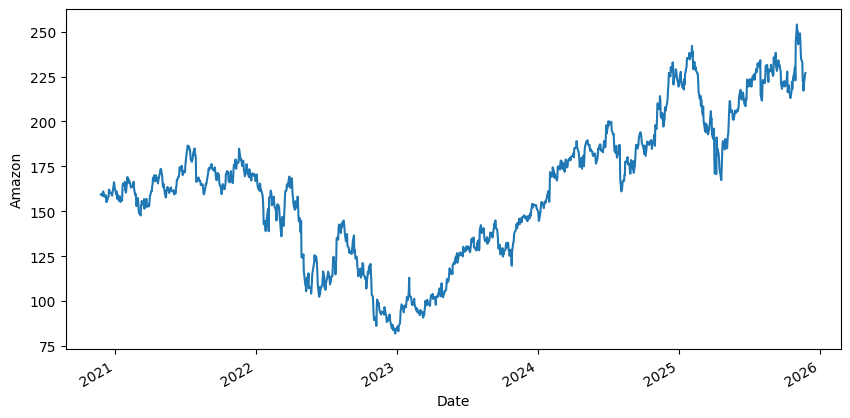

In [ ]:
#setting the text on the y-axis
plt.ylabel('Amazon')

#setting the size of our graph
data['Close'].plot(figsize=(10,5))

In [ ]:
#calculate simple moving averagee (5MA)
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()

#calculate exponential moving averages (EMA)
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

#calculate relative strength indes (RSI)
delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data['RSi'] = 100 - (100 / (1 + rs))

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSi
Date,,,,,,,,,,,
2020-11-25 00:00:00-05:00,157.093506,159.899994,157.013000,159.253494,75808000,0.0,0.0,NaN,NaN,159.253494,NaN
2020-11-27 00:00:00-05:00,160.563004,160.809494,159.502502,159.766998,47858000,0.0,0.0,NaN,NaN,159.302399,NaN
2020-11-30 00:00:00-05:00,160.423996,161.419495,156.277496,158.401993,81278000,0.0,0.0,NaN,NaN,159.216646,NaN
2020-12-01 00:00:00-05:00,159.425003,162.447495,157.858994,161.003998,90740000,0.0,0.0,NaN,NaN,159.386870,NaN
2020-12-02 00:00:00-05:00,161.082504,161.600006,158.662994,160.176498,62586000,0.0,0.0,NaN,NaN,159.462073,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-19 00:00:00-05:00,223.740005,223.740005,218.520004,222.690002,58335600,0.0,0.0,236.597501,228.1728,234.090739,49.889050
2025-11-20 00:00:00-05:00,227.050003,227.410004,216.740005,217.139999,50309000,0.0,0.0,236.400001,227.9166,232.476383,27.730263
2025-11-21 00:00:00-05:00,216.350006,222.210007,215.179993,220.690002,68490500,0.0,0.0,236.224001,227.7674,231.353870,19.479574


In [ ]:
# Dropping the NaN values
data = data.dropna()

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSi
Date,,,,,,,,,,,
2021-02-08 00:00:00-05:00,167.925003,168.250000,165.199997,166.147003,65148000,0.0,0.0,162.385099,160.74137,163.689976,64.976296
2021-02-09 00:00:00-05:00,165.624496,166.899994,164.891998,165.250000,44070000,0.0,0.0,162.862074,160.86130,163.838550,53.781422
2021-02-10 00:00:00-05:00,165.699997,165.897507,162.699997,164.328995,63032000,0.0,0.0,163.276449,160.95254,163.885259,48.056659
2021-02-11 00:00:00-05:00,164.600006,164.600006,162.403000,163.106506,46028000,0.0,0.0,163.517049,161.04663,163.811092,47.185990
2021-02-12 00:00:00-05:00,162.500000,164.012497,161.665497,163.885498,46706000,0.0,0.0,163.892649,161.10426,163.818178,48.515395
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-19 00:00:00-05:00,223.740005,223.740005,218.520004,222.690002,58335600,0.0,0.0,236.597501,228.17280,234.090739,49.889050
2025-11-20 00:00:00-05:00,227.050003,227.410004,216.740005,217.139999,50309000,0.0,0.0,236.400001,227.91660,232.476383,27.730263
2025-11-21 00:00:00-05:00,216.350006,222.210007,215.179993,220.690002,68490500,0.0,0.0,236.224001,227.76740,231.353870,19.479574


In [ ]:
# Initialising X and assigning the two feature variables
X = data[['EMA_20','SMA_50']]

# Getting the head of the data
X.head()

,EMA_20,SMA_50
Date,,
2021-02-08 00:00:00-05:00,163.689976,160.74137
2021-02-09 00:00:00-05:00,163.838550,160.86130
2021-02-10 00:00:00-05:00,163.885259,160.95254
2021-02-11 00:00:00-05:00,163.811092,161.04663
2021-02-12 00:00:00-05:00,163.818178,161.10426


In [ ]:
# Setting-up the dependent variable
y = data['Close']

# Getting the head of the data
y.head()

,Close
Date,
2021-02-08 00:00:00-05:00,166.147003
2021-02-09 00:00:00-05:00,165.250000
2021-02-10 00:00:00-05:00,164.328995
2021-02-11 00:00:00-05:00,163.106506
2021-02-12 00:00:00-05:00,163.885498


In [ ]:
# Setting the training set to 80% of the data
training = 0.7
t = int(training*len(data))

# Training dataset
X_train = X[:t]
y_train = y[:t]

# Testing dataset
X_test = X[t:]
y_test = y[t:]

In [ ]:
X[:t]

,EMA_20,SMA_50
Date,,
2021-02-08 00:00:00-05:00,163.689976,160.741370
2021-02-09 00:00:00-05:00,163.838550,160.861300
2021-02-10 00:00:00-05:00,163.885259,160.952540
2021-02-11 00:00:00-05:00,163.811092,161.046630
2021-02-12 00:00:00-05:00,163.818178,161.104260
...,...,...
2024-06-10 00:00:00-04:00,182.609401,182.660201
2024-06-11 00:00:00-04:00,183.049458,182.785400
2024-06-12 00:00:00-04:00,183.415224,182.909400


In [ ]:
from pycaret.regression import *
s = setup(
    data=data[['SMA_20','SMA_50','Close']],
    target='Close',
    session_id=123,
    numeric_features=['SMA_20', 'SMA_50'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)

,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1207, 3)"
4,Transformed data shape,"(1207, 3)"
5,Transformed train set shape,"(844, 3)"
6,Transformed test set shape,"(363, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


In [ ]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,11.0655,165.4813,12.8640,-2.5877,0.0751,0.0628
1,6.5364,55.8417,7.4727,-0.9245,0.0433,0.0388
2,12.4306,237.4837,15.4105,-1.3674,0.1009,0.0859
3,20.7660,554.0663,23.5386,-2.5799,0.1879,0.1850
4,10.3919,156.0777,12.4931,0.2883,0.1185,0.1030
5,6.4629,57.1823,7.5619,-0.5088,0.0790,0.0666
6,7.0089,76.6940,8.7575,0.4100,0.0771,0.0596
7,14.5862,265.2955,16.2879,-7.8338,0.1281,0.1082
8,8.8382,98.2567,9.9125,0.0242,0.0662,0.0572


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_rf = tune_model(rf)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,10.6631,153.5444,12.3913,-2.3289,0.0723,0.0605
1,5.6869,44.4162,6.6646,-0.5308,0.0388,0.0339
2,11.6469,205.2924,14.3280,-1.0465,0.0944,0.0803
3,28.6116,973.3938,31.1993,-5.2893,0.2405,0.2526
4,11.3232,186.2667,13.6480,0.1506,0.1282,0.1117
5,5.9485,48.5667,6.9690,-0.2815,0.0728,0.0620
6,9.7087,125.2753,11.1926,0.0362,0.1032,0.0846
7,11.6663,174.8070,13.2215,-4.8207,0.1021,0.0862
8,12.7539,183.1964,13.5350,-0.8194,0.0924,0.0829


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
print(tuned_rf)

RandomForestRegressor(max_depth=6, max_features='log2',
                      min_impurity_decrease=0.0002, min_samples_leaf=2,
                      n_estimators=290, n_jobs=-1, random_state=123)


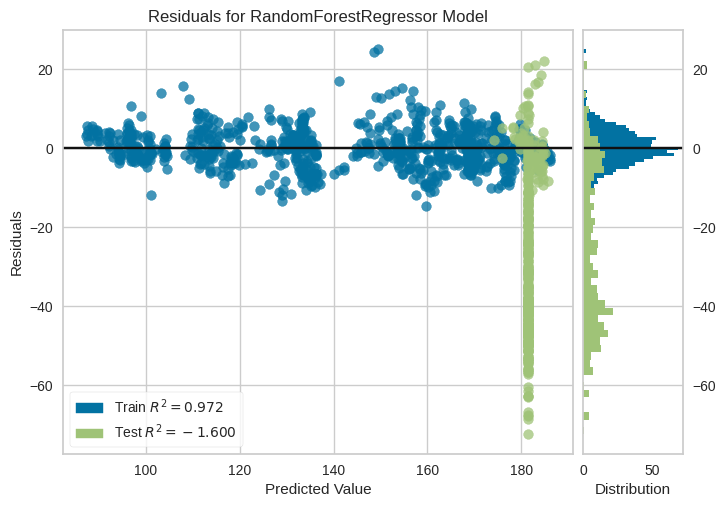

In [ ]:
plot_model(tuned_rf)

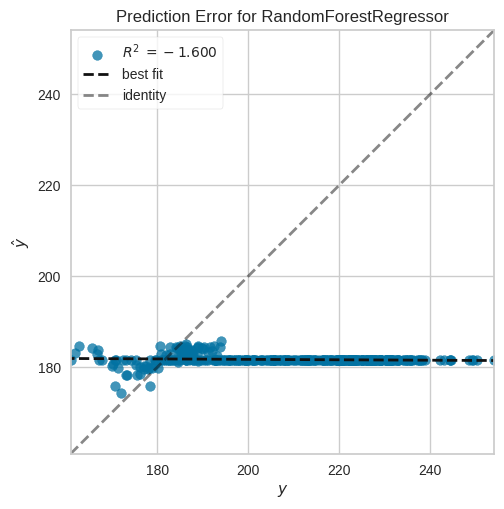

In [ ]:
plot_model(tuned_rf, plot = 'error')

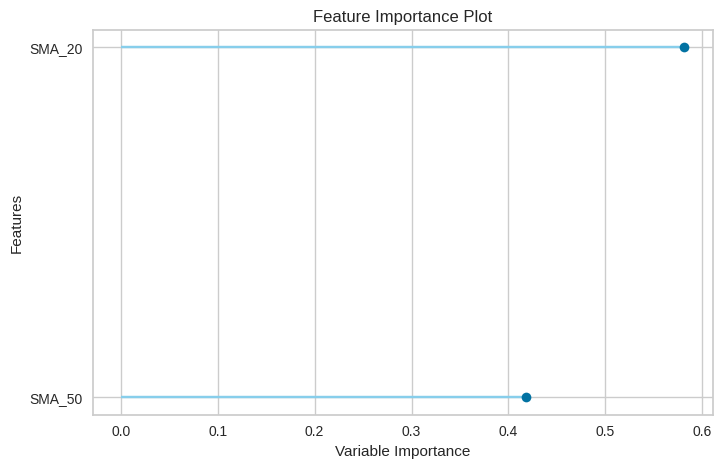

In [ ]:
plot_model(tuned_rf, plot = 'feature')

In [ ]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
predict_model(tuned_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,27.5332,1102.8233,33.2088,-1.6004,0.1629,0.1254


,SMA_20,SMA_50,Close,prediction_label
Date,,,,
2024-06-17 00:00:00-04:00,182.626999,182.990799,184.059998,184.547686
2024-06-18 00:00:00-04:00,182.590500,182.943207,182.809998,184.547686
2024-06-20 00:00:00-04:00,182.738007,182.951797,186.100006,184.582720
2024-06-21 00:00:00-04:00,183.035507,183.014404,189.080002,184.488811
2024-06-24 00:00:00-04:00,183.261505,182.944794,185.570007,183.403492
...,...,...,...,...
2025-11-19 00:00:00-05:00,236.597504,228.172806,222.690002,181.551009
2025-11-20 00:00:00-05:00,236.399994,227.916595,217.139999,181.551009
2025-11-21 00:00:00-05:00,236.223999,227.767395,220.690002,181.551009


In [ ]:
final_rf = finalize_model(tuned_rf)

In [ ]:
print(final_rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['SMA_20', 'SMA_50'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 RandomForestRegressor(max_depth=6, max_features='log2',
                                       min_impurity_decrease=0.0002,
                                       min_samples_leaf=2, n_estimators=290,
                                       n_jobs=-1, random_state=123))])


In [ ]:
predict_model(final_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,5.3255,50.8646,7.1319,0.8801,0.0341,0.0257


,SMA_20,SMA_50,Close,prediction_label
Date,,,,
2024-06-17 00:00:00-04:00,182.626999,182.990799,184.059998,184.542993
2024-06-18 00:00:00-04:00,182.590500,182.943207,182.809998,184.513154
2024-06-20 00:00:00-04:00,182.738007,182.951797,186.100006,184.544916
2024-06-21 00:00:00-04:00,183.035507,183.014404,189.080002,184.868103
2024-06-24 00:00:00-04:00,183.261505,182.944794,185.570007,184.532015
...,...,...,...,...
2025-11-19 00:00:00-05:00,236.597504,228.172806,222.690002,226.017645
2025-11-20 00:00:00-05:00,236.399994,227.916595,217.139999,225.988717
2025-11-21 00:00:00-05:00,236.223999,227.767395,220.690002,227.052666
